## Performance Prediction & Composition via Stochastic Network Calculus (SNC)

This notebook implements the probabilistic end-to-end performance modeling methodology using Gaussian Process (GP) regression, Moment Generating Function (MGF) derivation for Stochastic Network Calculus (SNC), and Min-Plus Convolution Composition. It includes diagnostic visualizations for model fit, coverage, and bound tightness.

In [1]:
# ==============================================================================
# Performance Prediction & Composition via SNC
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler

# Set global seed for reproducibility
np.random.seed(35)

# Global SLA / Risk target across all notebook steps
alpha = 0.05  # Violation probability (alpha = 0.0001 -> 99.99% SLA guarantee)
z_score = norm.ppf(1 - alpha)

# Format dynamic percentile label (e.g., '99.99' or '95')
p_pct = (1 - alpha) * 100
p_str = f"{p_pct:.2f}".rstrip('0').rstrip('.')

## 1. Synthetic Data Generation
We simulate execution time demands for a pipeline of three microservices ($s_1 \to s_2 \to s_3$) driven by system parameters: [CPU, Quality, Parallelism].

In [2]:

def true_demand(x, service_type):
    """Simulates latency demand d(x) = f(cpu, quality, parallelism)."""
    cpu, quality, parallelism = x[:, 0], x[:, 1], x[:, 2]
    if service_type == "type_A":
        # CPU scaling increased (0.008 -> 0.040), Quality scaling increased (0.005 -> 0.030, exponent 1.2 -> 2.0)
        return 0.010 + 0.040 / cpu + 0.030 * (quality ** 2.0)
    elif service_type == "type_B":
        # CPU scaling increased (0.005 -> 0.035), Quality scaling increased (0.007 -> 0.025)
        return 0.012 + 0.035 / cpu + 0.025 * (quality ** 1.5)
    else:
        # CPU scaling increased (0.004 -> 0.030), Quality scaling increased (0.006 -> 0.020)
        return 0.008 + 0.030 / cpu + 0.020 * (quality ** 1.8)

n_train = 50
X_train = np.column_stack([
    np.random.uniform(0.5, 2.0, n_train),  # CPU
    np.random.uniform(0.5, 2.0, n_train),  # Quality
    np.random.uniform(1.0, 4.0, n_train)  # Parallelism
])

service_names = ["s1", "s2", "s3"]
service_types = ["type_A", "type_B", "type_C"]
y_train_dict = {}

# Noise scaled proportionally to the new dynamic latency range (~3% to 5% coefficient of variation)
noise_levels = {
    "s1": 0.0060,  # ~5ms std (High variance node)
    "s2": 0.0010,  # ~2ms std (Low variance / stable node)
    "s3": 0.0035   # ~3.5ms std (Medium variance node)
}

for s_name, s_type in zip(service_names, service_types):
    y_clean = true_demand(X_train, s_type)
    noise = np.random.normal(0, noise_levels[s_name], n_train)
    y_train_dict[s_name] = y_clean + noise

print("Training dataset successfully generated.")

Training dataset successfully generated.


## 2. Learning Stage (Gaussian Process Surrogate Models)

We train a GP for each service to capture execution time distributions, decomposing epistemic (model) and aleatoric (noise) uncertainties.

In [3]:
class ScaledGPRegressor:
    """
    Wrapper around GaussianProcessRegressor that handles feature (X) scaling
    and leverages native `normalize_y=True` for target scaling.

    Explicitly decomposes total predictive variance V[Y(x)] into:
    - Epistemic uncertainty: Var(f(x))
    - Aleatoric uncertainty: sigma_n^2 (from WhiteKernel, unscaled to physical units)
    """
    def __init__(self, kernel, n_restarts_optimizer=5, random_state=42):
        self.x_scaler = StandardScaler()
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,  # Handles y-scaling natively & unscales predict() outputs
            n_restarts_optimizer=n_restarts_optimizer,
            random_state=random_state
        )

    def fit(self, X, y):
        X_scaled = self.x_scaler.fit_transform(X)
        self.gp.fit(X_scaled, y)
        return self

    def predict(self, X, return_std=False, return_variance_components=False):
        X_scaled = self.x_scaler.transform(X)

        # Epistemic standard deviation sqrt(Var(f(x))) - natively unscaled by sklearn
        mu, std_epistemic = self.gp.predict(X_scaled, return_std=True)
        var_epistemic = std_epistemic ** 2

        # Extract target scaling factor (sigma_y) used internally when normalize_y=True
        y_std = getattr(self.gp, '_y_train_std', 1.0)
        y_var_scale = y_std ** 2

        # Extract aleatoric noise level sigma_n^2 and convert from scaled space to physical units
        if hasattr(self.gp.kernel_, 'k2') and hasattr(self.gp.kernel_.k2, 'noise_level'):
            var_aleatoric_scaled = self.gp.kernel_.k2.noise_level
            var_aleatoric = np.full_like(var_epistemic, var_aleatoric_scaled * y_var_scale)
        else:
            var_aleatoric = np.zeros_like(var_epistemic)

        # Total variance V[Y(x)] = Var(f(x)) + sigma_n^2 (all in physical units)
        var_total = var_epistemic + var_aleatoric
        std_total = np.sqrt(var_total)

        if return_variance_components:
            return mu, std_total, var_epistemic, var_aleatoric
        if return_std:
            return mu, std_total

        return mu


def train_gp_models(X_train: np.ndarray, y_train_dict: dict, service_names: list) -> dict:
    """Fits ScaledGPRegressor models for each service."""
    models = {}
    for name in service_names:
        kernel = (
            C(1.0, (1e-2, 1e2)) * Matern(length_scale=1.0, nu=2.5) +
            WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 1e-1))
        )

        model = ScaledGPRegressor(kernel=kernel, n_restarts_optimizer=5, random_state=42)
        model.fit(X_train, y_train_dict[name])
        models[name] = model

    return models

gp_models = train_gp_models(X_train, y_train_dict, service_names)
print("Trained GP models for all microservices.")

Trained GP models for all microservices.


## 3. Visualization: Fitted GPs along a Feature Slice

Here we visualize the GP predictive distributions along a slice varying CPU while fixing Quality and Parallelism.

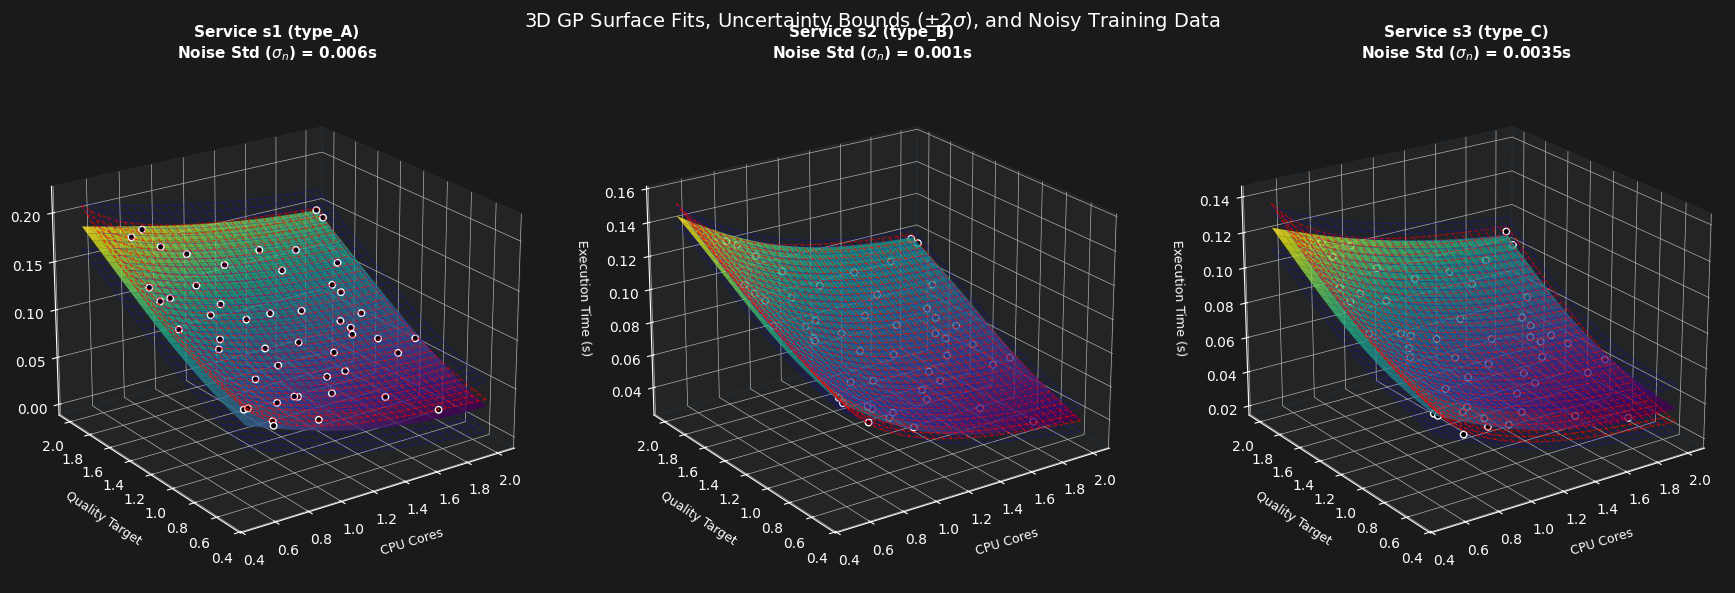

In [4]:
from mpl_toolkits.mplot3d import Axes3D

# Create 2D grid across both CPU (cores) and Quality
n_grid = 30
cpu_axis = np.linspace(0.5, 2.0, n_grid)
quality_axis = np.linspace(0.5, 2.0, n_grid)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)  # fixed parallelism

# Flatten grid for predictions
X_grid_3d = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

fig = plt.figure(figsize=(18, 6), dpi=100)

for idx, (s_name, s_type) in enumerate(zip(service_names, service_types), 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')

    # Predict GP mean and standard deviation across 2D grid
    mu, std = gp_models[s_name].predict(X_grid_3d, return_std=True)
    mu_surface = mu.reshape(n_grid, n_grid)
    std_surface = std.reshape(n_grid, n_grid)

    # 1. Plot GP Predicted Mean Surface (Solid Mesh)
    surf_mean = ax.plot_surface(
        CPU_grid, QUALITY_grid, mu_surface,
        cmap='viridis', alpha=0.8, edgecolor='none', label=r"GP Mean $\mu(x)$"
    )

    # 2. Plot GP Uncertainty Envelope (+- 2 std) as transparent wireframes
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface + 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Upper Bound ($\mu + 2\sigma$)"
    )
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, mu_surface - 2 * std_surface,
        color='blue', linewidth=0.5, alpha=0.3, label=r"Lower Bound ($\mu - 2\sigma$)"
    )

    # 3. Plot True Demand (Red Dashed Wireframe)
    y_true_surface = true_demand(X_grid_3d, s_type).reshape(n_grid, n_grid)
    ax.plot_wireframe(
        CPU_grid, QUALITY_grid, y_true_surface,
        color='red', linewidth=0.8, linestyle='--', alpha=0.6, label=r"True Demand $f(x)$"
    )

    # 4. Scatter Training Samples with Vertical Drop Lines to see 3D position clearly
    x_train_cpu = X_train[:, 0]
    x_train_qual = X_train[:, 1]
    y_train_obs = y_train_dict[s_name]

    # Draw vertical stem lines connecting each point to the GP Mean
    for x_c, x_q, y_o in zip(x_train_cpu, x_train_qual, y_train_obs):
        # Predict mean at specific point to draw residual stem
        mu_pt = gp_models[s_name].predict(np.array([[x_c, x_q, 2.0]]))
        ax.plot([x_c, x_c], [x_q, x_q], [mu_pt[0], y_o], color='black', alpha=0.4, linewidth=0.8)

    # Scatter actual noisy observations
    ax.scatter(
        x_train_cpu, x_train_qual, y_train_obs,
        color='black', s=22, edgecolors='white', alpha=1.0, zorder=10, label="Observed Training Data"
    )

    # Aesthetics & Labels
    ax.set_title(f"Service {s_name} ({s_type})\nNoise Std ($\\sigma_n$) = {noise_levels[s_name]}s", fontsize=11, fontweight='bold')
    ax.set_xlabel("CPU Cores", fontsize=9, labelpad=8)
    ax.set_ylabel("Quality Target", fontsize=9, labelpad=8)
    ax.set_zlabel("Execution Time (s)", fontsize=9, labelpad=8)
    ax.view_init(elev=22, azim=-125)

plt.suptitle(r"3D GP Surface Fits, Uncertainty Bounds ($\pm 2\sigma$), and Noisy Training Data", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## 4. Visualization: Coverage Analysis (Test Dataset)

We evaluate empirical coverage on a held-out test dataset to verify that the derived probabilistic bounds hold at the targeted violation probability $\alpha = 0.05$ (95% coverage).

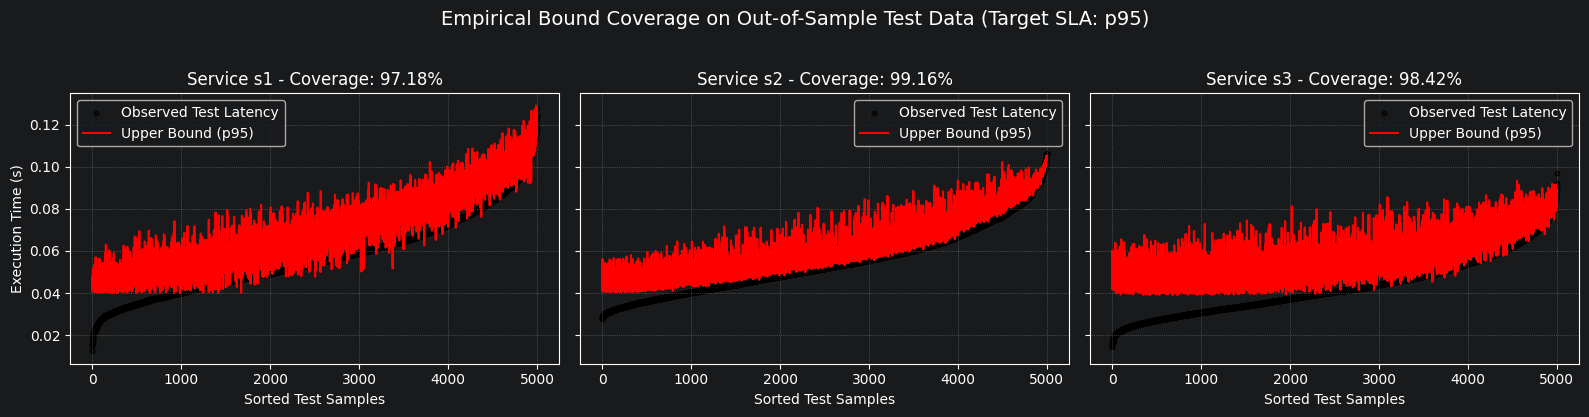

In [5]:
n_test = 5000
X_test = np.column_stack([
    np.random.uniform(0.5, 2.0, n_test),
    np.random.uniform(0.0, 1.0, n_test),
    np.random.uniform(1.0, 4.0, n_test)
])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, s_name, s_type in zip(axes, service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + (z_score * std_test)
    coverage = np.mean(y_true_test <= upper_bound) * 100

    sort_idx = np.argsort(y_true_test)

    ax.scatter(range(n_test), y_true_test[sort_idx], color='black', alpha=0.6, s=12, label="Observed Test Latency")
    ax.plot(range(n_test), upper_bound[sort_idx], color='red', linewidth=1.5, label=f"Upper Bound (p{p_str})")

    ax.set_title(f"Service {s_name} - Coverage: {coverage:.2f}%")
    ax.set_xlabel("Sorted Test Samples")
    if s_name == "s1":
        ax.set_ylabel("Execution Time (s)")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(f"Empirical Bound Coverage on Out-of-Sample Test Data (Target SLA: p{p_str})", fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## 5. Visualization: Bound Tightness Analysis

Tightness measures the residual margin $\text{Bound}(x) - \text{Observed}(x)$. Lower positive values reflect a tight, non-pessimistic SNC bound.

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_265110/3581678931.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax.hist(tightness, bins=25, alpha=0.5, label=f"Service {s_name} Slack ($\mu$={np.mean(tightness):.4f}s)")


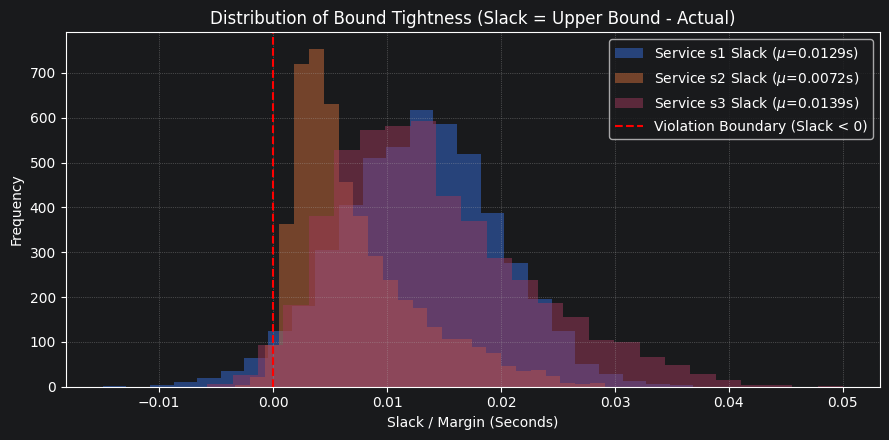

In [6]:

fig, ax = plt.subplots(figsize=(9, 4.5))

for s_name, s_type in zip(service_names, service_types):
    y_true_test = true_demand(X_test, s_type) + np.random.normal(0, noise_levels[s_name], n_test)
    mu_test, std_test = gp_models[s_name].predict(X_test, return_std=True)

    upper_bound = mu_test + z_score * std_test
    tightness = upper_bound - y_true_test

    ax.hist(tightness, bins=25, alpha=0.5, label=f"Service {s_name} Slack ($\mu$={np.mean(tightness):.4f}s)")

ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label="Violation Boundary (Slack < 0)")
ax.set_title("Distribution of Bound Tightness (Slack = Upper Bound - Actual)", fontsize=12)
ax.set_xlabel("Slack / Margin (Seconds)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 6. Deriving SNC Service Curves via MGFs
Using the predictive mean $\mu_i(x)$ and variance $\sigma_i^2(x)$ from the GP, we evaluate the closed-form Moment Generating Function (MGF) $M_Y(\theta) = \mathbb{E}[e^{\theta Y}] = \exp\left(\theta \mu + \frac{\theta^2}{2}\sigma^2\right)$ to obtain probabilistic service rate guarantees.

In [7]:

# TODO: Old function; don't really know what changed

# def compute_snc_mgf_service_curve(model, x_test, theta=100.0, target_eps=0.05):
#     """Computes MGF-backed SNC guaranteed service rate."""
#     mu, std = model.predict(x_test, return_std=True)
#     var = std ** 2
#     log_mgf = theta * mu + 0.5 * (theta ** 2) * var
#     guaranteed_rate = (theta / log_mgf) - (np.log(target_eps) / (theta * log_mgf))
#     guaranteed_rate = np.maximum(guaranteed_rate, 1e-6)
#     return guaranteed_rate, mu, std, log_mgf


# ==============================================================================
# 6. Deriving SNC Service Curves & Latency Bounds via MGFs
# ==============================================================================

def compute_snc_mgf_delay_bound(model, x_cfg, alpha=0.01):
    """
    Computes the MGF-backed SNC single-node delay bound D_i(x) for target violation prob alpha.

    Using log M_Y(theta) = theta*mu + (theta^2 / 2)*var, Chernoff's bound gives:
    P(Y >= D) <= exp(log M_Y(theta) - theta*D) = alpha
    Solving for optimal theta* yields: theta* = sqrt(-2*ln(alpha) / var)
    Plugging theta* back yields: D_i(alpha) = mu + sqrt(-2*ln(alpha) * var)
    """
    mu, std_total, var_epistemic, var_aleatoric = model.predict(x_cfg, return_variance_components=True)
    var_total = std_total ** 2

    # Node-optimal MGF theta parameter
    theta_opt = np.sqrt(-2.0 * np.log(alpha) / var_total)

    # Closed-form log-MGF evaluated at theta*
    log_mgf_opt = theta_opt * mu + 0.5 * (theta_opt ** 2) * var_total

    # Minimum physical latency bound satisfying target violation probability alpha
    delay_bound = (log_mgf_opt - np.log(alpha)) / theta_opt

    return delay_bound, theta_opt, mu, std_total

## 7. Composition & End-to-End Performance Analysis

Using min-plus convolution composition, we combine the probabilistic service curves into an end-to-end pipeline rate guarantee.

In [8]:
# Nominal Operating Point Configuration
x_pipeline_cfg = np.array([[1.0, 1.0, 2.0]])  # [CPU, Quality, Parallelism]

# ------------------------------------------------------------------------------
# A. Node-Level Evaluation & Metric Collection
# ------------------------------------------------------------------------------
node_mus = []
node_stds = []
node_rates = []

print("\n=== Individual Node Performance Guarantees ===")
for s_name in service_names:
    model = gp_models[s_name]

    # Predict mean and standard deviation
    mu, std = model.predict(x_pipeline_cfg, return_std=True)
    var = std[0]**2

    # Node-optimal theta* tailored to individual node variance
    # theta_node_opt = np.sqrt(2 * -np.log(alpha) / var)

    # Evaluate guaranteed rate using node-optimal theta*
    rate, _, _, _ = compute_snc_mgf_delay_bound(
        model, x_pipeline_cfg, alpha=alpha
    )

    node_mus.append(mu[0])
    node_stds.append(std[0])
    node_rates.append(rate[0])

    print(
        f"Service {s_name:2s} | "
        # f"Opt Theta = {theta_node_opt:7.1f} s^-1 | "
        f"Guaranteed Rate = {rate[0]:7.4f} units/s | "
        f"Pred Latency = {mu[0]:.4f}s (std = {std[0]:.4f})"
    )


=== Individual Node Performance Guarantees ===
Service s1 | Guaranteed Rate =  0.1053 units/s | Pred Latency = 0.0808s (std = 0.0100)
Service s2 | Guaranteed Rate =  0.0763 units/s | Pred Latency = 0.0723s (std = 0.0016)
Service s3 | Guaranteed Rate =  0.0696 units/s | Pred Latency = 0.0587s (std = 0.0045)


In [9]:

# ------------------------------------------------------------------------------
# B. End-to-End Optimization & Convolution
# ------------------------------------------------------------------------------
mu_total = sum(node_mus)
var_total = sum(std ** 2 for std in node_stds)
std_total = np.sqrt(var_total)

# Global optimal theta* for end-to-end composition variance
theta_opt = np.sqrt(2 * -np.log(alpha) / var_total)

# E2E Log-MGF sum
e2e_log_mgf_opt = theta_opt * mu_total + 0.5 * (theta_opt ** 2) * var_total

# Physical latency bound (seconds)
e2e_latency_bound_opt = (e2e_log_mgf_opt - np.log(alpha)) / theta_opt
e2e_bottleneck_rate = min(node_rates)

# ------------------------------------------------------------------------------
# C. Empirical Oracle Real Latency (Monte Carlo Ground Truth)
# ------------------------------------------------------------------------------
np.random.seed(42)
n_samples = 100_000

# simulated_latencies = np.zeros(n_samples)
# for s_name in service_names:
#     model = gp_models[s_name]
#     mu_s, std_s = model.predict(x_pipeline_cfg, return_std=True)
#     simulated_latencies += np.random.normal(mu_s[0], std_s[0], n_samples)
#
# oracle_real_p_latency = np.percentile(simulated_latencies, (1 - alpha) * 100)

simulated_latencies = np.zeros(n_samples)
for s_name, s_type in zip(service_names, service_types):
    # Sample from physical ground truth true_demand() instead of GP prediction
    true_latent = true_demand(x_pipeline_cfg, s_type)[0]
    simulated_latencies += np.random.normal(true_latent, noise_levels[s_name], n_samples)

oracle_real_p_latency = np.percentile(simulated_latencies, (1 - alpha) * 100)

# ------------------------------------------------------------------------------
# D. Baselines Summary
# ------------------------------------------------------------------------------
# TODO: I also don't understand how the confidence is messed up with this
b1_sum_of_means = mu_total
b2_naive_sum_p = sum(m + z_score * s for m, s in zip(node_mus, node_stds))
b3_joint_gaussian_p = mu_total + z_score * std_total
# TODO: I don't really understand yet what's the benefit of the SNC vs the joint gaussian
b4_snc_mgf_bound = e2e_latency_bound_opt
b5_oracle_real_p = oracle_real_p_latency

print("\n=== End-to-End Composite Pipeline Performance ===")
print(f"E2E Bottleneck Service Rate Guarantee : {e2e_bottleneck_rate:.4f} units/s")
print(f"Optimal MGF Parameter (theta*)        : {theta_opt:.2f} s^-1")
print(f"E2E Convoluted Log-MGF Bound (M_Y)     : {e2e_log_mgf_opt:.6f} (unitless)")

print("\n" + "=" * 80)
print(f"{'E2E LATENCY BOUND COMPARISON (target alpha = ' + str(alpha) + ')':^80}")
print("=" * 80)
print(f"{'Method / Baseline':<35} | {'Latency (s)':<12} | {'Notes / Interpretation'}")
print("-" * 80)
print(f"{'1. Sum of Means (E[Y])':<35} | {b1_sum_of_means:<12.4f} | Mean execution time only (no tail risk)")
print(f"{f'2. Naive Sum of p{p_str} Bounds':<35} | {b2_naive_sum_p:<12.4f} | Over-pessimistic (assumes all nodes spike simultaneously)")
print(f"{f'3. Joint Gaussian {p_str}% Quantile':<35} | {b3_joint_gaussian_p:<12.4f} | Parametric baseline assuming Gaussian distribution")
print(f"{'4. Optimized SNC MGF Bound (theta*)':<35} | {b4_snc_mgf_bound:<12.4f} | Non-parametric network calculus tail guarantee")
print(f"{f'5. Empirical Oracle Real p{p_str}':<35} | {b5_oracle_real_p:<12.4f} | Ground truth measured via Monte Carlo (100k runs)")
print("=" * 80)


=== End-to-End Composite Pipeline Performance ===
E2E Bottleneck Service Rate Guarantee : 0.0696 units/s
Optimal MGF Parameter (theta*)        : 221.04 s^-1
E2E Convoluted Log-MGF Bound (M_Y)     : 49.814374 (unitless)

               E2E LATENCY BOUND COMPARISON (target alpha = 0.05)               
Method / Baseline                   | Latency (s)  | Notes / Interpretation
--------------------------------------------------------------------------------
1. Sum of Means (E[Y])              | 0.2118       | Mean execution time only (no tail risk)
2. Naive Sum of p95 Bounds          | 0.2383       | Over-pessimistic (assumes all nodes spike simultaneously)
3. Joint Gaussian 95% Quantile      | 0.2300       | Parametric baseline assuming Gaussian distribution
4. Optimized SNC MGF Bound (theta*) | 0.2389       | Non-parametric network calculus tail guarantee
5. Empirical Oracle Real p95        | 0.2215       | Ground truth measured via Monte Carlo (100k runs)


/tmp/ipykernel_265110/1965831537.py:54: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/boris/development/composable-autonomous-offerings/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


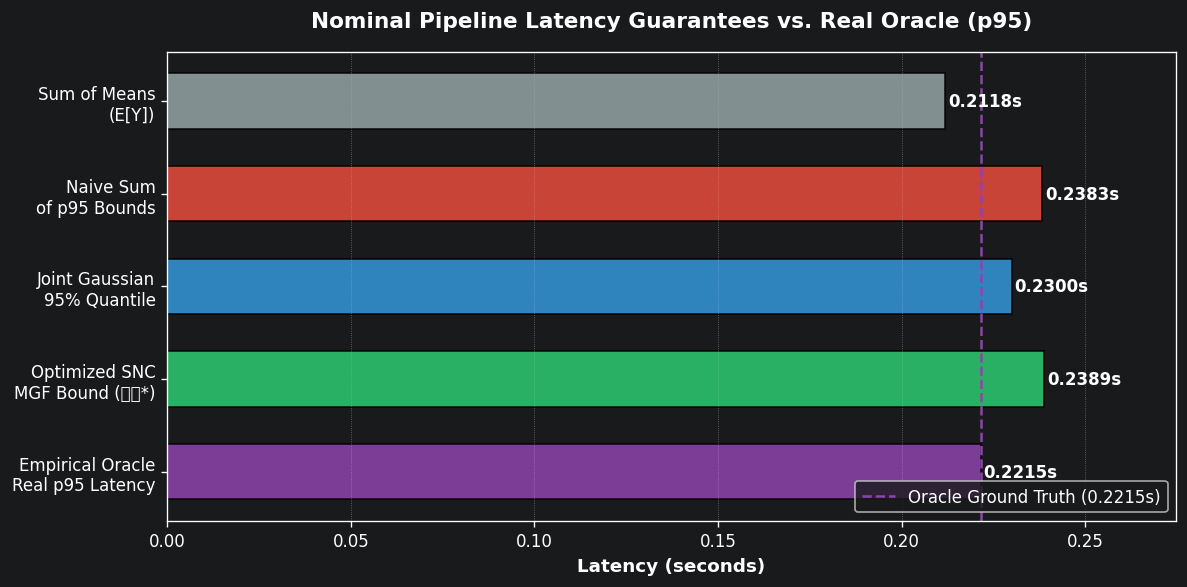

In [10]:

# ------------------------------------------------------------------------------
# E. Visualization: Nominal Configuration Bar Chart
# ------------------------------------------------------------------------------
labels = [
    'Sum of Means\n(E[Y])',
    f'Naive Sum\nof p{p_str} Bounds',
    f'Joint Gaussian\n{p_str}% Quantile',
    'Optimized SNC\nMGF Bound (﷿﷿*)',
    f'Empirical Oracle\nReal p{p_str} Latency'
]
values = [
    b1_sum_of_means,
    b2_naive_sum_p,
    b3_joint_gaussian_p,
    b4_snc_mgf_bound,
    b5_oracle_real_p
]
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71', '#8e44ad']

plt.figure(figsize=(10, 5), dpi=120)
bars = plt.barh(labels, values, color=colors, edgecolor='black', alpha=0.85, height=0.6)

plt.axvline(
    x=b5_oracle_real_p,
    color='#8e44ad',
    linestyle='--',
    linewidth=1.5,
    label=f'Oracle Ground Truth ({b5_oracle_real_p:.4f}s)'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.0008,
        bar.get_y() + bar.get_height()/2,
        f'{width:.4f}s',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, max(values) * 1.15)
plt.xlabel('Latency (seconds)', fontsize=11, fontweight='bold')
plt.title(
    f'Nominal Pipeline Latency Guarantees vs. Real Oracle (p{p_str})',
    fontsize=13,
    fontweight='bold',
    pad=15
)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

## 8. Design Space Sensitivity & Sweep Analysis

To ensure our SNC bounds hold consistently across different system allocations, we sweep CPU availability ($0.5 \to 2.0$) while tracking bound tightness and pessimism.

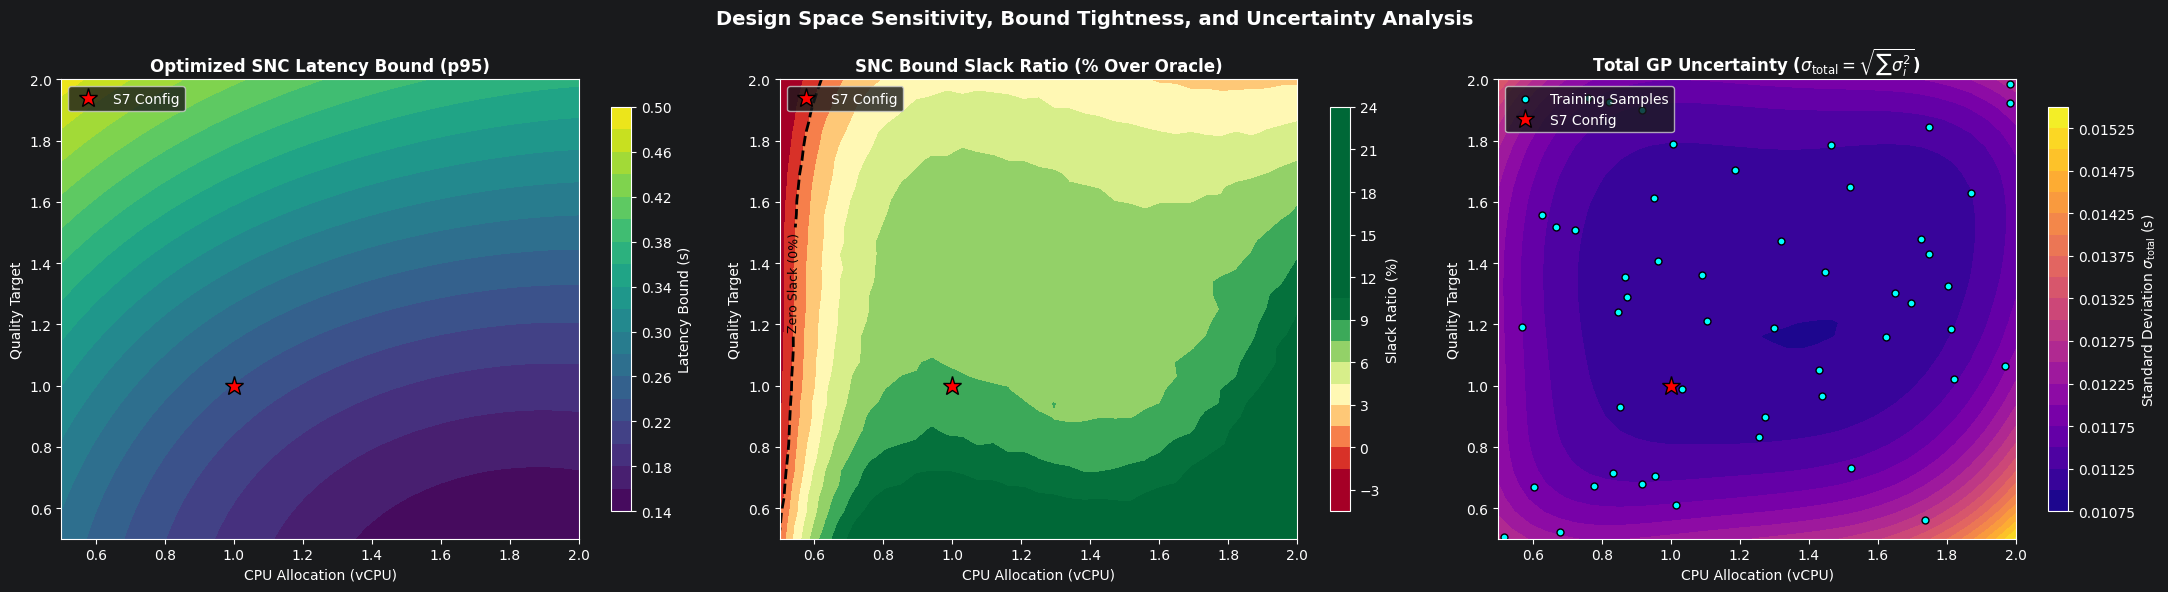

In [11]:
# ------------------------------------------------------------------------------
# A. Build 2D Meshgrid & Storage Matrices
# ------------------------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

n_grid = 35  # 35 x 35 = 1,225 evaluation points
cpu_axis = np.linspace(0.5, 2.0, n_grid)
quality_axis = np.linspace(0.5, 2.0, n_grid)

CPU_grid, QUALITY_grid = np.meshgrid(cpu_axis, quality_axis)
PARALLELISM_grid = np.full_like(CPU_grid, 2.0)

# Flatten grid for batched GP predictions
X_2d_sweep = np.column_stack([
    CPU_grid.ravel(),
    QUALITY_grid.ravel(),
    PARALLELISM_grid.ravel()
])

n_points_2d = X_2d_sweep.shape[0]

snc_surface = np.zeros(n_points_2d)
oracle_surface = np.zeros(n_points_2d)
slack_surface = np.zeros(n_points_2d)
std_total_surface = np.zeros(n_points_2d)

np.random.seed(42)
n_mc_samples = 5_000  # Monte Carlo sample count per grid point

# ------------------------------------------------------------------------------
# B. Consolidated Loop: Evaluate SNC Bounds, Oracle Ground Truth, & Uncertainty
# ------------------------------------------------------------------------------
for i in range(n_points_2d):
    cfg = X_2d_sweep[i:i + 1]

    # 1. GP predictions across services
    mus = []
    stds = []
    for s_name in service_names:
        mu_s, std_s = gp_models[s_name].predict(cfg, return_std=True)
        mus.append(mu_s[0])
        stds.append(std_s[0])

    mu_tot_i = sum(mus)
    var_tot_i = sum(s ** 2 for s in stds)
    std_tot_i = np.sqrt(var_tot_i)

    # 2. Optimal SNC MGF Bound
    theta_opt_i = np.sqrt(2 * -np.log(alpha) / var_tot_i)
    e2e_log_mgf_i = theta_opt_i * mu_tot_i + 0.5 * (theta_opt_i ** 2) * var_tot_i
    snc_bound_i = (e2e_log_mgf_i - np.log(alpha)) / theta_opt_i

    # 3. Monte Carlo Oracle Ground Truth (true physical demand)
    mc_sim = np.zeros(n_mc_samples)
    for s_name, s_type in zip(service_names, service_types):
        true_latent = true_demand(cfg, s_type)[0]
        mc_sim += np.random.normal(true_latent, noise_levels[s_name], n_mc_samples)
    oracle_p_i = np.percentile(mc_sim, (1 - alpha) * 100)

    # 4. Store values
    snc_surface[i] = snc_bound_i
    oracle_surface[i] = oracle_p_i
    slack_surface[i] = ((snc_bound_i - oracle_p_i) / oracle_p_i) * 100
    std_total_surface[i] = std_tot_i

# Reshape flattened results back to 2D matrix shape
SNC_matrix = snc_surface.reshape(n_grid, n_grid)
Oracle_matrix = oracle_surface.reshape(n_grid, n_grid)
Slack_matrix = slack_surface.reshape(n_grid, n_grid)
Std_Total_matrix = std_total_surface.reshape(n_grid, n_grid)

# ------------------------------------------------------------------------------
# C. Side-by-Side Unified Plotting (1 Row x 3 Columns - Clean 2D Grid)
# ------------------------------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6), dpi=100)

# S7 nominal configuration point
s7_cpu = x_pipeline_cfg[0, 0]
s7_quality = x_pipeline_cfg[0, 1]
s7_label = f'S7 Config'

# Subplot 1: Absolute Latency Bound Surface (2D Contour)
c1 = ax1.contourf(CPU_grid, QUALITY_grid, SNC_matrix, levels=20, cmap='viridis')
fig.colorbar(c1, ax=ax1, shrink=0.88, label='Latency Bound (s)')
ax1.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)
ax1.set_title(f'Optimized SNC Latency Bound (p{p_str})', fontsize=12, fontweight='bold')
ax1.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax1.set_ylabel('Quality Target', fontsize=10)
ax1.legend(loc='upper left', frameon=True)

# Subplot 2: Bound Slack Ratio Heatmap (2D Contour)
c2 = ax2.contourf(CPU_grid, QUALITY_grid, Slack_matrix, levels=20, cmap='RdYlGn', vmin=-2.0, vmax=10.0)
fig.colorbar(c2, ax=ax2, shrink=0.88, label='Slack Ratio (%)')
ax2.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)
contour_zero = ax2.contour(CPU_grid, QUALITY_grid, Slack_matrix, levels=[0.0], colors='black', linewidths=2.0, linestyles='--')
ax2.clabel(contour_zero, inline=True, fmt='Zero Slack (0%%)', fontsize=9)
ax2.set_title('SNC Bound Slack Ratio (% Over Oracle)', fontsize=12, fontweight='bold')
ax2.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax2.set_ylabel('Quality Target', fontsize=10)
ax2.legend(loc='upper left', frameon=True)

# Subplot 3: Total GP Uncertainty Surface (2D Contour - Perfectly Aligned)
c3 = ax3.contourf(CPU_grid, QUALITY_grid, Std_Total_matrix, levels=20, cmap='plasma')
fig.colorbar(c3, ax=ax3, shrink=0.88, label=r'Standard Deviation $\sigma_{\mathrm{total}}$ (s)')

# Scatter training data points
ax3.scatter(X_train[:, 0], X_train[:, 1], color='cyan', edgecolors='black', s=25, label='Training Samples')

# Plot S7 point
ax3.plot(s7_cpu, s7_quality, 'r*', markersize=14, markeredgecolor='black', label=s7_label)

ax3.set_title(r'Total GP Uncertainty ($\sigma_{\mathrm{total}} = \sqrt{\sum \sigma_i^2}$)', fontsize=12, fontweight='bold')
ax3.set_xlabel('CPU Allocation (vCPU)', fontsize=10)
ax3.set_ylabel('Quality Target', fontsize=10)
ax3.legend(loc='upper left', frameon=True)

plt.suptitle("Design Space Sensitivity, Bound Tightness, and Uncertainty Analysis", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [12]:
# # 2D Active Learning Heatmap
# plt.figure(figsize=(8, 6), dpi=100)
# c = plt.contourf(CPU_grid, QUALITY_grid, Std_Total_matrix, levels=20, cmap='plasma')
# plt.colorbar(c, label=r'GP Uncertainty $\sigma_{\mathrm{total}}$ (s)')
#
# # Highlight maximum uncertainty point (where to sample next)
# max_idx = np.argmax(std_total_surface)
# plt.plot(X_2d_sweep[max_idx, 0], X_2d_sweep[max_idx, 1], 'r*', markersize=15,
#          label='Next Recommended Training Sample')
#
# plt.scatter(X_train[:, 0], X_train[:, 1], color='cyan', edgecolors='black', s=30, label='Existing Training Data')
# plt.title('Active Learning Guide: Regions Needing More Telemetry', fontsize=12, fontweight='bold')
# plt.xlabel('CPU Allocation (vCPU)')
# plt.ylabel('Quality Target')
# plt.legend(loc='lower right')
# plt.show()